# W2 

## A qubit in superposition


In [44]:
import qiskit as qk
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import numpy as np
import math

# Uncomment this line if needed in Jupyter
#%matplotlib inline

Circuit:


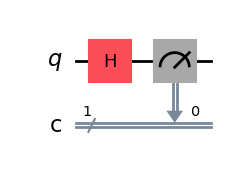

Measurement counts: {'0': 512, '1': 512}


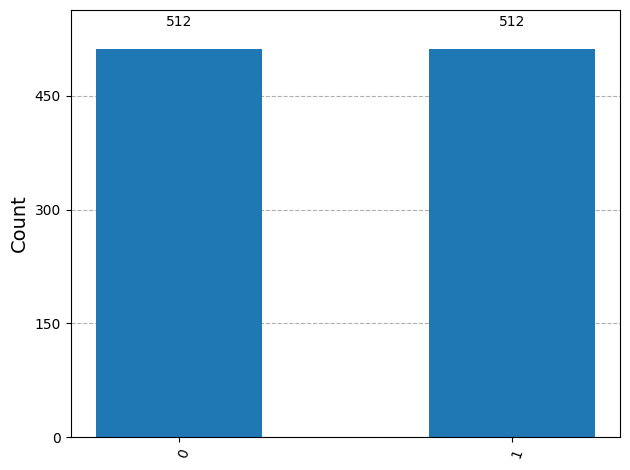

In [45]:
# Example 1: One qubit in superposition
qc1 = QuantumCircuit(1, 1)

# Apply Hadamard gate
qc1.h(0)

# Measure the qubit
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))
plt.close()

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)

### Activity 1: A qubit in superposition

1. Why do we not get only `0` as the result?

#### Because after the `H` gate the state of the qubit changes from $|0\rangle$ to $\frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle$, giving a 50% the probabilities to get 1 $(P(1)=|\beta|^2)$

2. Are the counts exactly equal? Why or why not?

#### No, the counts are not exactly equal Because it is a statistical variation, meaning the result fluctuates around the probability of 50/50

3. What do you think will happen if the `H` gate is removed?

#### If the `H` gate is removed, the qubit stays in its initial state $|0\rangle$, therefore the probability of measuring `0` is 100% and the probability of measuring 1 is 0%


Circuit:


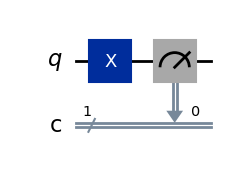

Measurement counts: {'1': 1024}


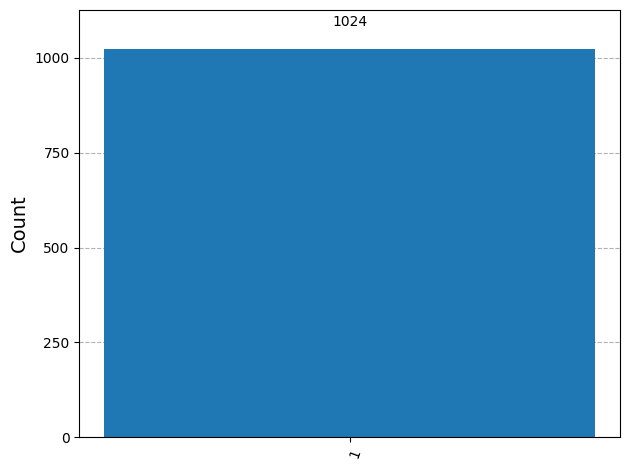

In [46]:
"""Try it yourself
Modify the circuit:
- remove the `H` gate and run again
- replace `qc1.h(0)` with `qc1.x(0)` and run again
Write one sentence explaining each outcome."""

qc1 = QuantumCircuit(1, 1)

qc1.x(0)

# Measure the qubit
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))
plt.close()

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)


The X gate flip the Qubit $|0\rangle \to |1\rangle$. Initial stated without H gate is 0, thus after X gate it's 1.


## Two qubits in superposition

Circuit:


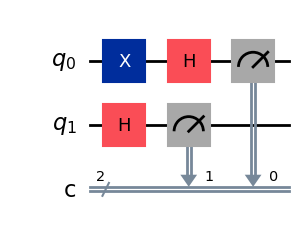

Measurement counts: {'00': 276, '10': 242, '11': 253, '01': 253}


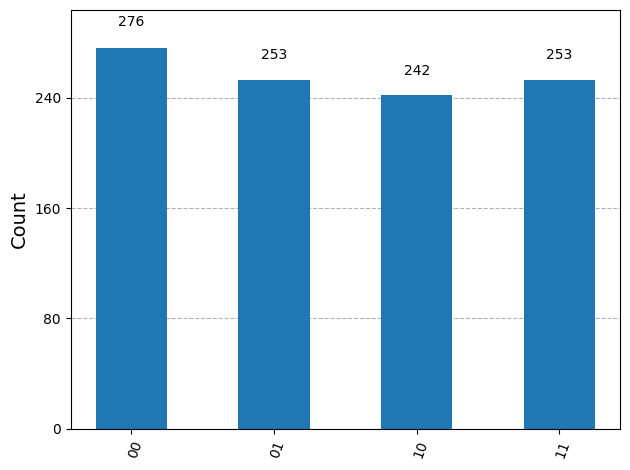

In [47]:
# Example 2: Two qubits in superposition
qc2 = qk.QuantumCircuit(2, 2)

qc2.x(0)
qc2.h(0)
qc2.h(1)


qc2.measure(0, 0)
qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))
plt.close()

simulator = AerSimulator()
job = simulator.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

### Activity 2: Two qubits in superposition

1. Why are there four possible outputs now?
#### Because the circuit has two qubits in superposition. Each qubit has a 50% probability of being measured as `0` or `1`, so the possible two-qubit outputs are `00`, `01`, `10`, and `11`. Each output has an expected probability of about 25%.
2. Which output appears most often? Is that what you expected?
#### No single output should always appear most often. Since the two qubits are in equal superposition, the four outputs `00`, `01`, `10`, and `11` should appear with similar counts. However, because of statistical variation, one output may appear slightly more often in a run of 1024 shots.
3. If you apply `X` to qubit 0 before the `H`, how does the result change?
#### It does not significantly change the measurement results. The `X` gate changes qubit 0 from `|0⟩` to `|1⟩`, but after the `H` gate the qubit is still placed into an equal superposition. The only difference is a phase change, which does not affect the measurement probabilities in this circuit. Therefore, the outputs should still appear with similar probabilities.

Circuit:


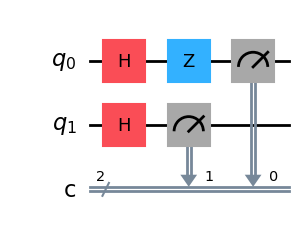

Measurement counts: {'01': 244, '10': 273, '00': 276, '11': 231}


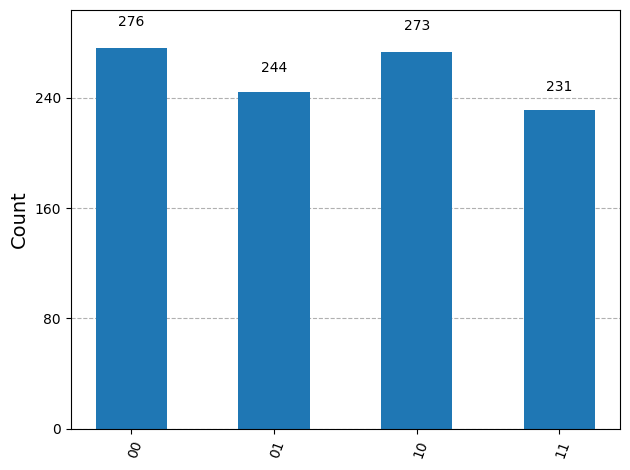

In [48]:
'''### Extension
Try the following one at a time:
- apply `X` on qubit 0 before measurement
- apply `Z` on qubit 0 before measurement
- measure only one qubit and leave the other unmeasured

What do you observe?'''


# Example 2: Two qubits in superposition
qc2 = qk.QuantumCircuit(2, 2)

qc2.h(0)
qc2.h(1)

#qc2.x(0)
qc2.z(0)

qc2.measure(0, 0)
qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

### The measurement results are almost the same. `X` after `H` does not change the output because the qubit is already in superposition, so swapping the polarity of the amplitude still gives 50% change of getting `0` and `1`. Similarity, applying `Z` changes the phase, but this change does not affect the final measurement probabilities

## Entanglement

Circuit:


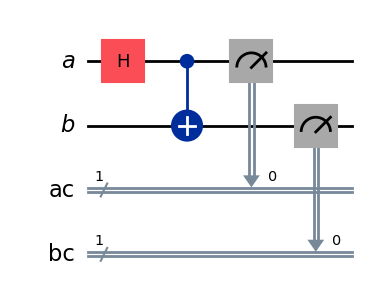

Measurement counts: {'0 0': 2027, '1 1': 2069}


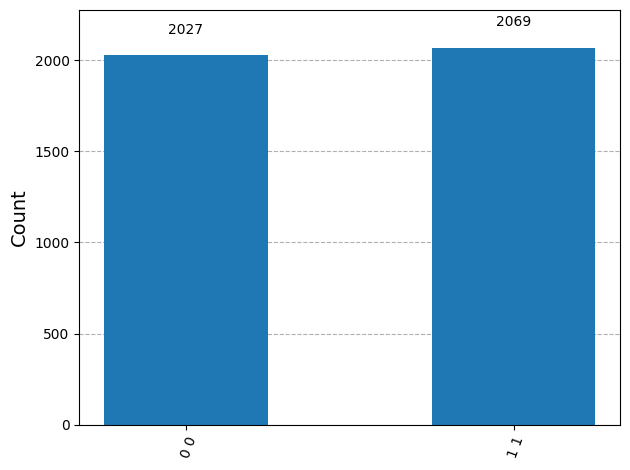

In [49]:
# Example 3: Entangled qubits
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 3: Entanglement


1. Why do we mainly see `00` and `11`, but not `01` and `10`?
### The CNOT gate flips the target (qubit 1) when the control (qubit 0) is 1 and does it nothing when the control is `0`; thus, the results after CNOT can only be 00 and `11`, making the qubits correlated or entangled.
2. How is this different from the earlier two-qubit superposition example?
### In example 2, the measurements of each qubit are independent, and both are in superposition, but independently, that's the main reason it shows `00 01 10 11`. On the other hand, in example 3, both qubits are entangled through the CNOT gate, making the results of the measurement only of two possibilities, `00` and `11`
3. What role does the `cx` gate play?
### The CNOT gate creates a correlation between two qubits when it flips the target qubit when the value of the control qubit in superposition is 1. This produces the entangled state where both qubits are measured either `00` and `11`

Circuit:


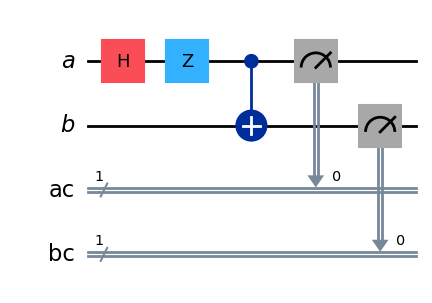

Measurement counts: {'1 1': 2018, '0 0': 2078}


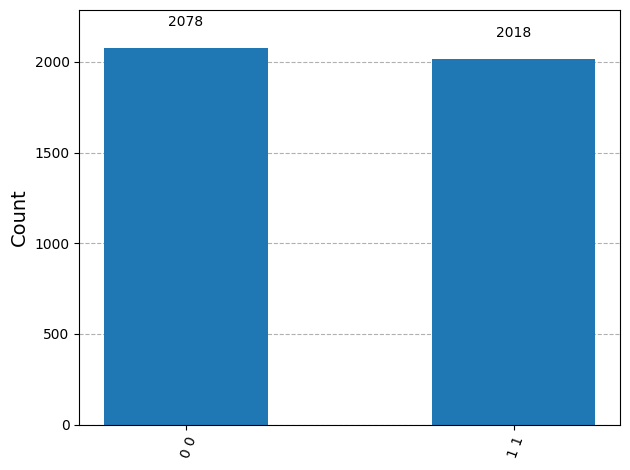

In [50]:
'''Try it yourself
Change the circuit and test:
- remove the `cx` gate
- apply `x` to qubit `b` before measurement
- apply `z` to qubit `a` before the `cx`

Describe what changes in the histogram.'''

# Example 3: Entangled qubits
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition

qc3.z(a[0])
qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
#qc3.x(b[0])

qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

- remove the `cx` gate
### two qubits, one in superposition and the other one in initial state `0`, having as a results `00 01`
- apply `x` to qubit `b` before measurement
### `X` gates flips the state of qubit b, showing a viceversa results `10 11`
- apply `z` to qubit `a` before the `cx`
### Gate `Z` changes the phase of $\beta$ from positive to negative, but following the conservation law, the results are the same: $P(1)=\left|-\frac{1}{\sqrt{2}}\right|^2=\frac{1}{2}$ $P(0)=50\%,\quad P(1)=50\%$




# Bloch Sphere

Statevector for |0>: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


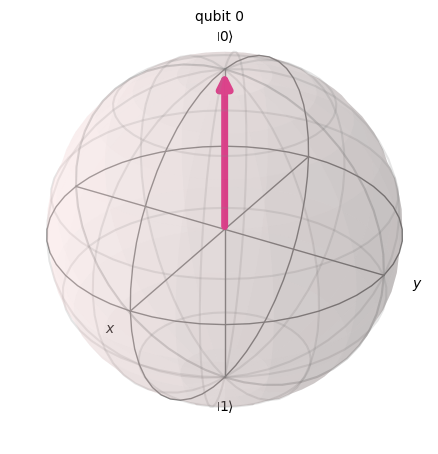

In [51]:
# Bloch Sphere for |0>
qc_b0 = QuantumCircuit(1)
state_b0 = Statevector.from_instruction(qc_b0)

print("Statevector for |0>:", state_b0)
plot_bloch_multivector(state_b0)

Statevector for |1>: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


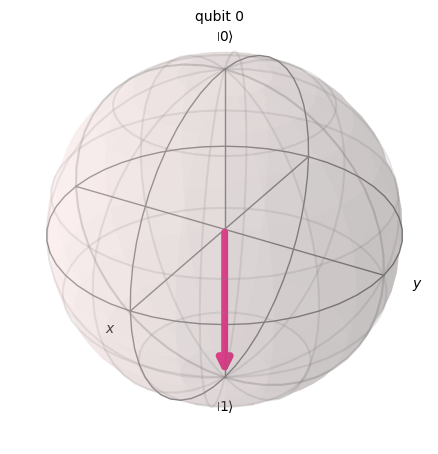

In [52]:
# Bloch Sphere for |1>
qc_b1 = QuantumCircuit(1)
qc_b1.x(0)
state_b1 = Statevector.from_instruction(qc_b1)

print("Statevector for |1>:", state_b1)
plot_bloch_multivector(state_b1)

Statevector for H|0>: Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


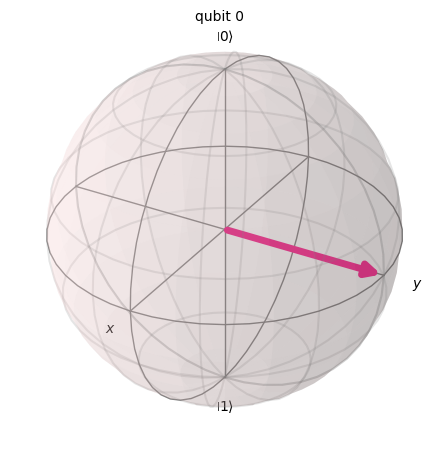

In [55]:
# Bloch Sphere for H|0>
qc_bh = QuantumCircuit(1)
qc_bh.h(0)
qc_bh.s(0)
state_bh = Statevector.from_instruction(qc_bh)

print("Statevector for H|0>:", state_bh)
plot_bloch_multivector(state_bh)

### Class activity 4: Bloch Sphere

For each state above, identify whether the point is:

- near the north pole 
- near the south pole 
- on the equator

Then answer:
1. Where is \(|0\rangle\)?
### North Pole
2. Where is \(|1\rangle\)?
### South Pole
3. What type of state is created by `H|0>`?
### Ecuador, superposition
4. Why is the Bloch Sphere mainly useful for only one qubit?
### A single qubit can be mapped by two complex numbers onto the Block sphere, for more than that the number of amplitudes increase exponentially, making impossible to represents in a 3D diagram  